In [1]:
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [7]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

df = pd.read_csv(DATA_DIR / "manifests/cityscapes_pairs.csv")
df.head()

,split,city,image_path,mask_path
0,train,aachen,leftImg8bit/train/aachen/aachen_000000_000019_...,gtFine/train/aachen/aachen_000000_000019_gtFin...
1,train,aachen,leftImg8bit/train/aachen/aachen_000001_000019_...,gtFine/train/aachen/aachen_000001_000019_gtFin...
2,train,aachen,leftImg8bit/train/aachen/aachen_000002_000019_...,gtFine/train/aachen/aachen_000002_000019_gtFin...
3,train,aachen,leftImg8bit/train/aachen/aachen_000003_000019_...,gtFine/train/aachen/aachen_000003_000019_gtFin...
4,train,aachen,leftImg8bit/train/aachen/aachen_000004_000019_...,gtFine/train/aachen/aachen_000004_000019_gtFin...


In [8]:
df['split'].value_counts()

split
train    2975
val       500
Name: count, dtype: int64

(-0.5, 2047.5, 1023.5, -0.5)

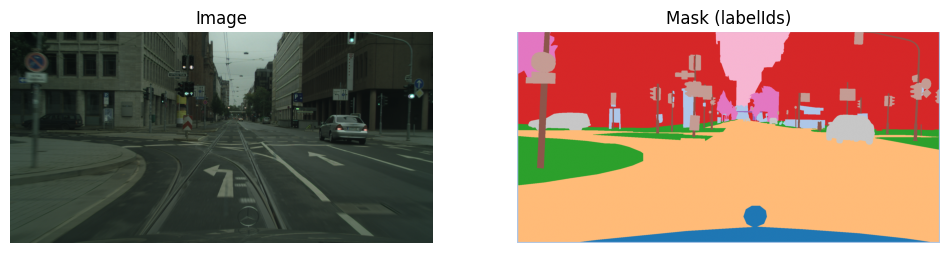

In [11]:
row = df.sample(1).iloc[0]

img_path = PROJECT_ROOT / "data" / row.image_path
mask_path = PROJECT_ROOT / "data" / row.mask_path

img = np.array(Image.open(img_path))
mask = np.array(Image.open(mask_path))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="tab20")
plt.title("Mask (labelIds)")
plt.axis("off")

In [12]:
unique_values = np.unique(mask)
unique_values

array([ 1,  3,  4,  6,  7,  8, 11, 15, 17, 18, 19, 20, 21, 23, 26, 33],
      dtype=uint8)

In [14]:
all_labels = set()

for path in df["mask_path"].sample(100):
    mask = np.array(Image.open(PROJECT_ROOT / "data" / path))
    all_labels.update(np.unique(mask))

sorted(all_labels)

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 15,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33]

In [15]:
img.shape, mask.shape

((1024, 2048, 3), (1024, 2048))